In [2]:
BATCH_SIZE   = 32
EPOCHS       = 200
LR           = 0.001
WEIGHT_DECAY = 1e-4
N_HEADS      = 5
FF_FACTOR    = 8
DROPOUT      = 0.4
TRAIN_N      = 240
VAL_N        = 60

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")



class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=36):
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])  # ← fix
        self.register_buffer('pe', pe)

    def forward(self):
        return self.pe

class ALPEModule(nn.Module):
    def __init__(self, d_model, max_len=36):
        super().__init__()
        self.conv = nn.Conv1d(d_model, d_model,
                              kernel_size=3, padding=1, bias=False)
        self.eca  = ECAModule(d_model)
        self.pe   = PositionalEncoding(d_model, max_len)

    def forward(self, mask):
        pe   = self.pe().unsqueeze(0)
        mask = mask.unsqueeze(-1)
        pe   = pe * mask
        pe   = pe.transpose(1, 2)
        pe   = self.conv(pe)
        pe   = self.eca(pe)
        return pe.transpose(1, 2)


class CNNSubModule(nn.Module):
    def __init__(self, d_model, kernel_size=3, dropout=0.2):
        super().__init__()
        pad          = kernel_size // 2
        self.conv1   = nn.Conv1d(d_model, d_model, kernel_size,
                                 padding=pad, bias=False)
        self.norm1   = nn.BatchNorm1d(d_model)
        self.conv2   = nn.Conv1d(d_model, d_model, kernel_size,
                                 padding=pad, bias=False)
        self.norm2   = nn.BatchNorm1d(d_model)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x   = x.transpose(1, 2)
        res = x
        out = self.relu(self.norm1(self.conv1(x)))
        out = self.dropout(out)
        out = self.norm2(self.conv2(out))
        out = self.relu(out + res)
        return out.transpose(1, 2)


class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_heads=5, use_alpe=False,
                 max_len=36, ff_factor=8, dropout=0.2):
        super().__init__()
        self.use_alpe = use_alpe

        if use_alpe:
            self.pe = ALPEModule(d_model, max_len)
        else:
            self.pe = PositionalEncoding(d_model, max_len)

        self.attention = nn.MultiheadAttention(
            d_model, n_heads, batch_first=True, dropout=dropout
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, d_model * ff_factor),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(d_model * ff_factor, d_model)
        )
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, mask=None):
        if self.use_alpe:
            pe = self.pe(mask)
        else:
            pe = self.pe().unsqueeze(0)

        x           = x + pe
        attn_out, _ = self.attention(x, x, x)
        x           = self.norm1(x + self.dropout(attn_out))
        x           = self.norm2(x + self.dropout(self.ff(x)))
        return x


class CTFusionModule(nn.Module):
    def __init__(self, d_model, n_heads=5, kernel_size=3,
                 use_alpe=False, max_len=36, ff_factor=8, dropout=0.2):
        super().__init__()
        self.cnn         = CNNSubModule(d_model, kernel_size, dropout)
        self.transformer = TransformerSubModule(
            d_model, n_heads, use_alpe, max_len, ff_factor, dropout
        )

    def forward(self, x, mask=None):
        cnn_out   = self.cnn(x)
        trans_out = self.transformer(x, mask)
        return torch.cat([cnn_out, trans_out], dim=-1)


class MCTNet(nn.Module):
    def __init__(self, num_classes, n_bands=10, n_steps=36,
                 n_heads=5, ff_factor=8, dropout=0.2):
        super().__init__()
        self.n_bands = n_bands  # ← stocker pour forward

        self.stage1 = CTFusionModule(
            d_model=n_bands, n_heads=n_heads, use_alpe=True,
            max_len=n_steps, ff_factor=ff_factor, dropout=dropout
        )
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.stage2 = CTFusionModule(
            d_model=n_bands * 2, n_heads=n_heads, use_alpe=False,
            max_len=n_steps // 2, ff_factor=ff_factor, dropout=dropout
        )
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.stage3 = CTFusionModule(
            d_model=n_bands * 4, n_heads=n_heads, use_alpe=False,
            max_len=n_steps // 4, ff_factor=ff_factor, dropout=dropout
        )

        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.dropout_out = nn.Dropout(p=dropout)
        self.mlp         = nn.Linear(n_bands * 8, num_classes)

    def forward(self, x, mask):
        if x.shape[2] != self.n_bands:  # ← fix : était codé en dur à 10
            x = x.transpose(1, 2)

        x = self.stage1(x, mask)
        x = x.transpose(1, 2)
        x = self.pool1(x)
        x = x.transpose(1, 2)

        x = self.stage2(x)
        x = x.transpose(1, 2)
        x = self.pool2(x)
        x = x.transpose(1, 2)

        x = self.stage3(x)
        x = x.transpose(1, 2)
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout_out(x)
        return self.mlp(x)



Device : cuda


In [24]:
class CropDataset(Dataset):
    def __init__(self, pixels, mask, labels_enc):
        self.X    = torch.tensor(pixels / 10000.0, dtype=torch.float32)
        self.mask = torch.tensor(mask,             dtype=torch.float32)
        self.y    = torch.tensor(labels_enc,       dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.mask[i], self.y[i]


def preparer_splits(labels_enc, train_n=240, val_n=60, seed=42):
    np.random.seed(seed)
    classes = np.unique(labels_enc)
    idx_tr, idx_val, idx_te = [], [], []
    for c in classes:
        idx_c = np.where(labels_enc == c)[0]
        np.random.shuffle(idx_c)
        tr = min(train_n, len(idx_c))
        v  = min(val_n,   len(idx_c) - tr)
        idx_tr .extend(idx_c[:tr])
        idx_val.extend(idx_c[tr:tr + v])
        idx_te .extend(idx_c[tr + v:])
    return np.array(idx_tr), np.array(idx_val), np.array(idx_te)

In [25]:
def entrainer(pixels, labels, zone_nom, classes,
              n_heads=N_HEADS, ff_factor=FF_FACTOR, dropout=DROPOUT,
              n_epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):

    print(f"\n{'='*55}")
    print(f"  ENTRAÎNEMENT — {zone_nom}")
    print(f"{'='*55}")

    classes_presentes = [c for c in classes if c in np.unique(labels)]
    le         = LabelEncoder()
    le.fit(classes_presentes)
    n_classes  = len(classes_presentes)
    labels_enc = le.transform(labels)
    print(f"  Classes : {classes_presentes}")

    mask   = (~np.all(pixels == 0, axis=2)).astype(np.float32)
    idx_tr, idx_val, idx_te = preparer_splits(labels_enc, TRAIN_N, VAL_N)
    print(f"  Train={len(idx_tr)} | Val={len(idx_val)} | Test={len(idx_te)}")

    tr_dl  = DataLoader(CropDataset(pixels[idx_tr],  mask[idx_tr],  labels_enc[idx_tr]),
                        batch_size=batch_size, shuffle=True, pin_memory=True)
    val_dl = DataLoader(CropDataset(pixels[idx_val], mask[idx_val], labels_enc[idx_val]),
                        batch_size=64, pin_memory=True)
    te_dl  = DataLoader(CropDataset(pixels[idx_te],  mask[idx_te],  labels_enc[idx_te]),
                        batch_size=64, pin_memory=True)


    model = MCTNet(
        num_classes=n_classes,
        n_bands=pixels.shape[2],
        n_steps=pixels.shape[1],
        n_heads=n_heads,
        ff_factor=ff_factor,
        dropout=dropout
    ).to(device)

    opt       = optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    crit      = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max',
                                                     factor=0.5, patience=20)

    print(f"  Paramètres : {sum(p.numel() for p in model.parameters()):,}")

    best_val_acc = 0.0
    best_state   = None
    history      = {'train_loss': [], 'val_acc': [], 'val_loss': []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        running_loss = 0.0
        for x, m, y in tr_dl:
            x, m, y = x.to(device), m.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x, m), y)
            loss.backward()
            opt.step()
            running_loss += loss.item() * len(y)
        train_loss = running_loss / len(tr_dl.dataset)

        model.eval()
        preds_v, trues_v = [], []
        val_loss_total   = 0.0
        with torch.no_grad():
            for x, m, y in val_dl:
                x, m, y = x.to(device), m.to(device), y.to(device)
                out = model(x, m)
                val_loss_total += crit(out, y).item() * len(y)
                preds_v.extend(out.argmax(1).cpu().numpy())
                trues_v.extend(y.cpu().numpy())
        val_acc  = accuracy_score(trues_v, preds_v)
        val_loss = val_loss_total / len(val_dl.dataset)
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 20 == 0:
            print(f"  Epoch {epoch:>3}/{n_epochs} | Train Loss={train_loss:.4f} "
                  f"| Val Loss={val_loss:.4f} | Best={best_val_acc:.4f}")

    model.load_state_dict(best_state)
    model.eval()
    preds_te, trues_te = [], []
    with torch.no_grad():
        for x, m, y in te_dl:
            x, m = x.to(device), m.to(device)
            preds_te.extend(model(x, m).argmax(1).cpu().numpy())
            trues_te.extend(y.numpy())

    oa    = accuracy_score(trues_te, preds_te)
    kappa = cohen_kappa_score(trues_te, preds_te)
    f1    = f1_score(trues_te, preds_te, average='macro', zero_division=0)

    ref_oa    = '0.968' if 'Arkansas'   in zone_nom else '0.852'
    ref_kappa = '0.951' if 'Arkansas'   in zone_nom else '0.806'
    ref_f1    = '0.933' if 'Arkansas'   in zone_nom else '0.829'
    print(f"\n  ── Résultats {zone_nom} ──────────────────")
    print(f"  {'Métrique':<8} {'Notre':>8} {'Article':>8}")
    print(f"  {'-'*26}")
    print(f"  {'OA':<8} {oa:>8.3f} {ref_oa:>8}")
    print(f"  {'Kappa':<8} {kappa:>8.3f} {ref_kappa:>8}")
    print(f"  {'F1':<8} {f1:>8.3f} {ref_f1:>8}")

    torch.save(
        {'model_state_dict': best_state, 'classes': classes_presentes,
         'oa': oa, 'kappa': kappa, 'f1': f1},
        dossier + f'/mctnet_{zone_nom.lower()}.pth'
    )
    print(f"  Modèle sauvegardé")

    return oa, kappa, f1, best_state, le, trues_te, preds_te, history

In [15]:
import numpy as np
# 1. Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/dataset'

# ── Chargement des données de base ──────────────────────────
AR_X       = np.load(f'{save_path}/AR_X.npy')        # (N, 360)
AR_y       = np.load(f'{save_path}/AR_y.npy')        # (N,)
CA_X       = np.load(f'{save_path}/CA_X.npy')        # (N, 360)
CA_y       = np.load(f'{save_path}/CA_y.npy')        # (N,)

# ── Chargement des covariables California ───────────────────
AR_climate = np.load(f'{save_path}/AR_climate.npy')  # (N, ?)
AR_soil    = np.load(f'{save_path}/AR_soil.npy')     # (N, ?)
AR_topo    = np.load(f'{save_path}/AR_topo.npy')     # (N, ?)

CA_climate = np.load(f'{save_path}/CA_climate.npy')  # (N, ?)
CA_soil    = np.load(f'{save_path}/CA_soil.npy')     # (N, ?)
CA_topo    = np.load(f'{save_path}/CA_topo.npy')     # (N, ?)

# ── Vérification des shapes ─────────────────────────────────
print("AR_X shape     :", AR_X.shape)
print("AR_y shape     :", AR_y.shape)
print("CA_X shape     :", CA_X.shape)
print("CA_y shape     :", CA_y.shape)
print("AR_climate     :", AR_climate.shape)
print("AR_soil        :", AR_soil.shape)
print("AR_topo        :", AR_topo.shape)
print("CA_climate     :", CA_climate.shape)
print("CA_soil        :", CA_soil.shape)
print("CA_topo        :", CA_topo.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AR_X shape     : (10000, 36, 10)
AR_y shape     : (10000,)
CA_X shape     : (10000, 36, 10)
CA_y shape     : (10000,)
AR_climate     : (10000, 36, 3)
AR_soil        : (10000, 3)
AR_topo        : (10000, 2)
CA_climate     : (10000, 36, 3)
CA_soil        : (10000, 3)
CA_topo        : (10000, 2)


In [26]:
def prepare_region(X, y, climate, soil, topo):
    N, T, B = X.shape

    le    = LabelEncoder()
    y_enc = le.fit_transform(y)

    def expand(arr):
        if arr.ndim == 2:                                         # (N, C) statique → (N, T, C)
            arr = np.repeat(arr[:, np.newaxis, :], T, axis=1)
        return arr.astype(np.float32)

    X = X.astype(np.float32)

    configs = {
        'S2_only'    : X,
        'S2_climate' : np.concatenate([X, expand(climate)],                          axis=2),
        'S2_soil'    : np.concatenate([X, expand(soil)],                             axis=2),
        'S2_topo'    : np.concatenate([X, expand(topo)],                             axis=2),
        'S2_all'     : np.concatenate([X, expand(climate), expand(soil), expand(topo)], axis=2),
    }
    return configs, y_enc, le


CA_configs, CA_y_enc, CA_le = prepare_region(CA_X, CA_y, CA_climate, CA_soil, CA_topo)
AR_configs, AR_y_enc, AR_le = prepare_region(AR_X, AR_y, AR_climate, AR_soil, AR_topo)

print("=== California ===")
print(f"  Classes encodées : {CA_le.classes_} → {list(range(len(CA_le.classes_)))}")
for name, arr in CA_configs.items():
    print(f"  {name:<20} : {arr.shape}")

print("\n=== Arkansas ===")
print(f"  Classes encodées : {AR_le.classes_} → {list(range(len(AR_le.classes_)))}")
for name, arr in AR_configs.items():
    print(f"  {name:<20} : {arr.shape}")

=== California ===
  Classes encodées : [  3  36  69  75 204 999] → [0, 1, 2, 3, 4, 5]
  S2_only              : (10000, 36, 10)
  S2_climate           : (10000, 36, 13)
  S2_soil              : (10000, 36, 13)
  S2_topo              : (10000, 36, 12)
  S2_all               : (10000, 36, 18)

=== Arkansas ===
  Classes encodées : [  1   2   3   5 999] → [0, 1, 2, 3, 4]
  S2_only              : (10000, 36, 10)
  S2_climate           : (10000, 36, 13)
  S2_soil              : (10000, 36, 13)
  S2_topo              : (10000, 36, 12)
  S2_all               : (10000, 36, 18)


In [27]:
for region, configs in [('California', CA_configs), ('Arkansas', AR_configs)]:
    print(f"\n=== {region} ===")
    for name, arr in configs.items():
        print(f"  {name:<20} : {arr.shape}  "
              f"min={arr.min():8.2f}  max={arr.max():8.2f}  "
              f"mean={arr.mean():8.2f}  std={arr.std():6.2f}")


=== California ===
  S2_only              : (10000, 36, 10)  min=    0.00  max= 8816.50  mean= 1685.11  std=1332.13
  S2_climate           : (10000, 36, 13)  min=    0.00  max= 8816.50  mean= 1340.19  std=1328.84
  S2_soil              : (10000, 36, 13)  min=    0.00  max= 8816.50  mean= 1302.67  std=1361.20
  S2_topo              : (10000, 36, 12)  min=    0.00  max= 8816.50  mean= 1410.28  std=1362.55
  S2_all               : (10000, 36, 18)  min=    0.00  max= 8816.50  mean=  976.57  std=1272.53

=== Arkansas ===
  S2_only              : (10000, 36, 10)  min=    0.00  max=15037.50  mean= 1668.81  std=1404.37
  S2_climate           : (10000, 36, 13)  min=    0.00  max=15037.50  mean= 1327.88  std=1381.60
  S2_soil              : (10000, 36, 13)  min=    0.00  max=15037.50  mean= 1289.00  std=1413.55
  S2_topo              : (10000, 36, 12)  min=    0.00  max=15037.50  mean= 1398.86  std=1417.03
  S2_all               : (10000, 36, 18)  min=    0.00  max=15037.50  mean=  968.31  std=

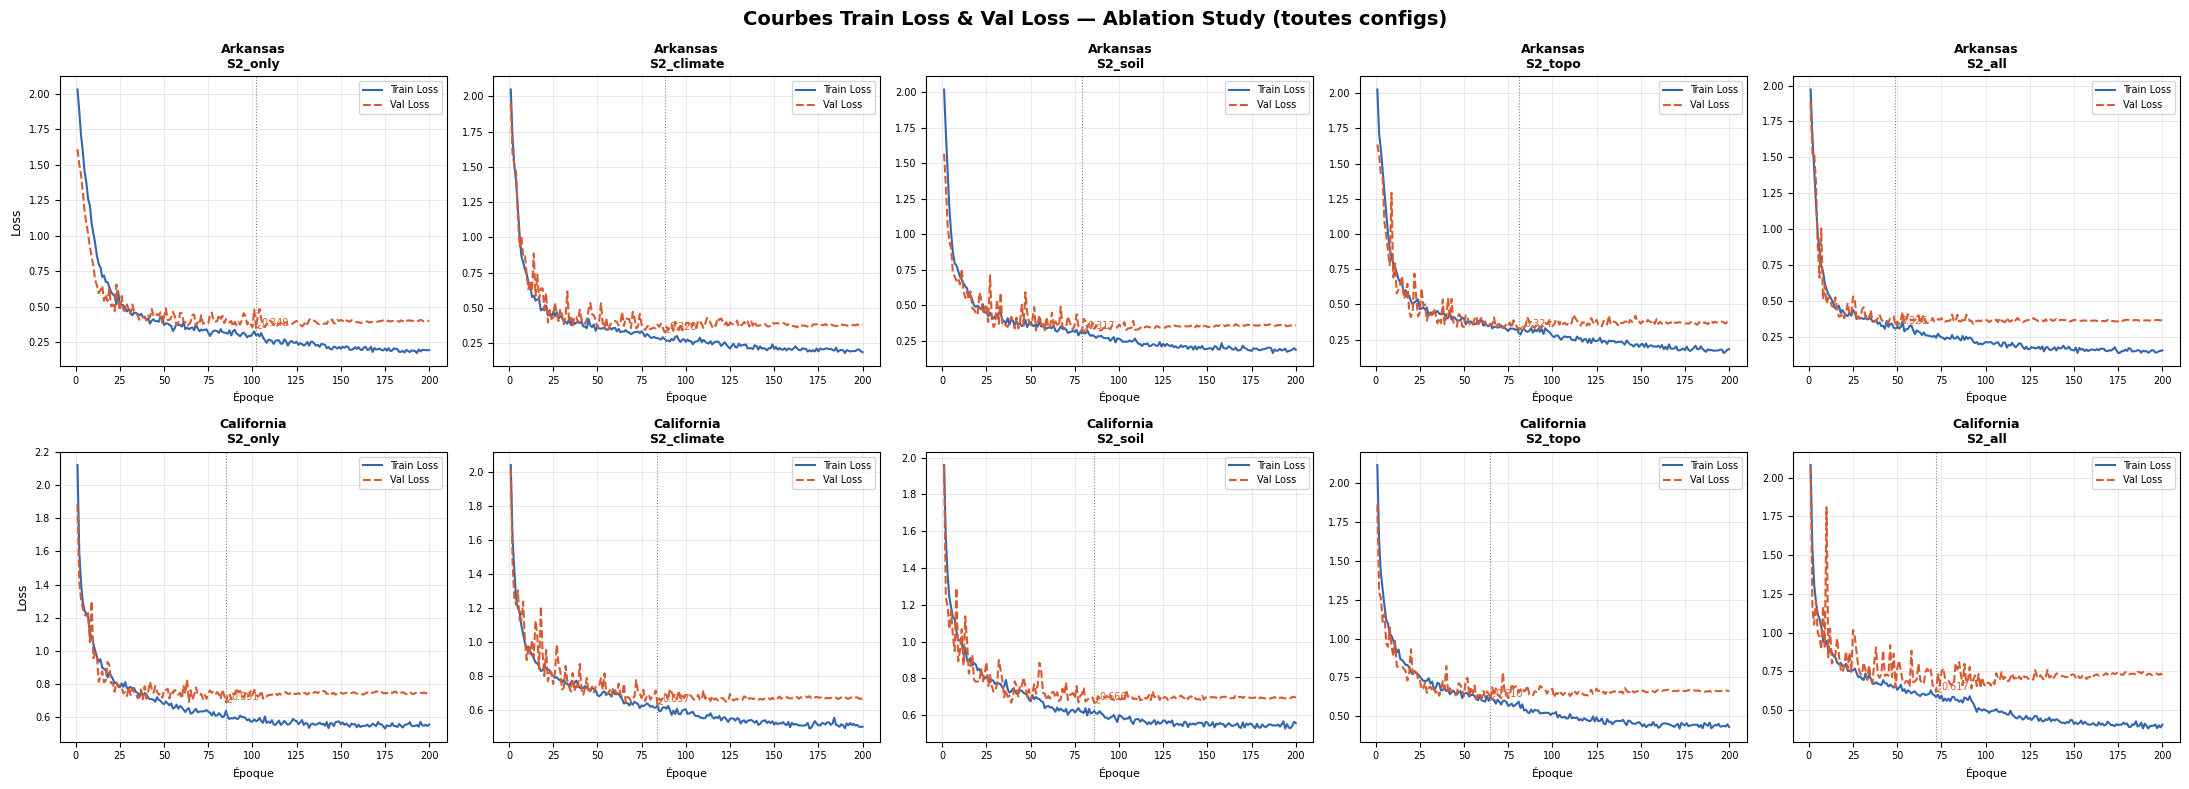

Figure sauvegardée : ablation_toutes_loss.png


In [34]:
import matplotlib.pyplot as plt
import numpy as np

configs_list = ['S2_only', 'S2_climate', 'S2_soil', 'S2_topo', 'S2_all']
regions_list = ['Arkansas', 'California']

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Courbes Train Loss & Val Loss — Ablation Study (toutes configs)',
             fontsize=14, fontweight='bold')

colors = {
    'train': '#3266ad',
    'val'  : '#d85a30',
}

for row_idx, region_name in enumerate(regions_list):
    for col_idx, cfg in enumerate(configs_list):
        ax   = axes[row_idx][col_idx]
        hist = results[region_name][cfg]['history']

        epochs = range(1, len(hist['train_loss']) + 1)

        l1, = ax.plot(epochs, hist['train_loss'],
                      color=colors['train'], linewidth=1.5, label='Train Loss')
        l2, = ax.plot(epochs, hist['val_loss'],
                      color=colors['val'],   linewidth=1.5,
                      linestyle='--', label='Val Loss')

        # Annotations min
        best_train_ep   = int(np.argmin(hist['train_loss'])) + 1
        best_train_loss = min(hist['train_loss'])
        best_val_ep     = int(np.argmin(hist['val_loss']))   + 1
        best_val_loss   = min(hist['val_loss'])

        ax.axvline(best_val_ep, color='gray', linewidth=0.8, linestyle=':')
        ax.annotate(f'{best_val_loss:.3f}',
                    xy=(best_val_ep, best_val_loss),
                    xytext=(best_val_ep + 3, best_val_loss + 0.015),
                    fontsize=7, color=colors['val'],
                    arrowprops=dict(arrowstyle='->', color=colors['val'], lw=0.7))

        ax.set_title(f'{region_name}\n{cfg}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Époque', fontsize=8)
        if col_idx == 0:
            ax.set_ylabel('Loss', fontsize=9)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, linewidth=0.4, alpha=0.5)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(dossier + '/ablation_toutes_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : ablation_toutes_loss.png")

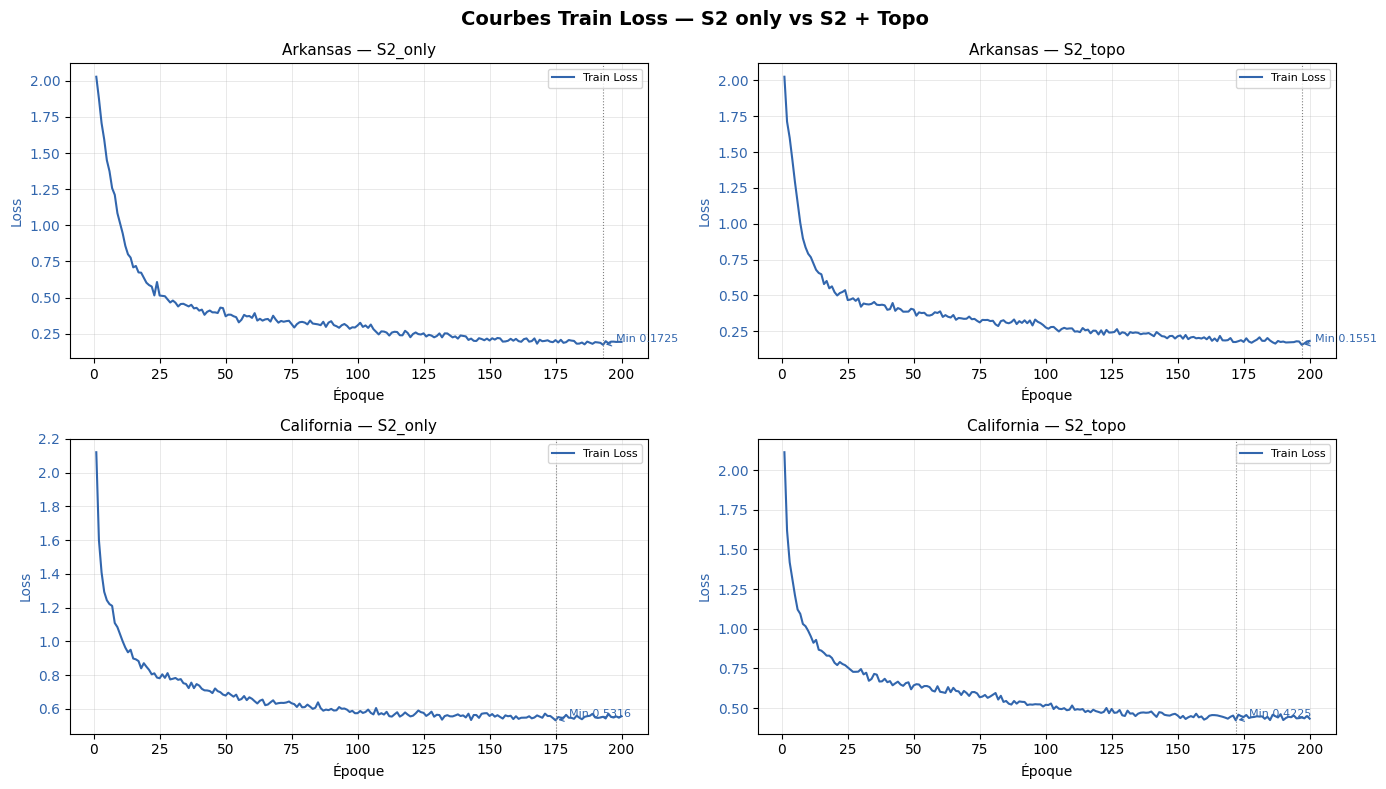

Figure sauvegardée.


In [33]:
import matplotlib.pyplot as plt
import numpy as np

configs_to_plot = ['S2_only', 'S2_topo']
regions = {
    'Arkansas':   (AR_configs, AR_y, results['Arkansas']),
    'California': (CA_configs, CA_y, results['California']),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Courbes Train Loss — S2 only vs S2 + Topo', fontsize=14, fontweight='bold')

for row_idx, (region_name, (_, _, res)) in enumerate(regions.items()):
    for col_idx, cfg in enumerate(configs_to_plot):
        ax = axes[row_idx][col_idx]
        hist = res[cfg]['history']

        epochs = range(1, len(hist['train_loss']) + 1)

        l1, = ax.plot(epochs, hist['train_loss'], color='#3266ad', linewidth=1.5, label='Train Loss')

        ax.set_xlabel('Époque', fontsize=10)
        ax.set_ylabel('Loss', fontsize=10, color='#3266ad')
        ax.tick_params(axis='y', labelcolor='#3266ad')

        # Marquer l'époque avec la loss minimale
        best_epoch = int(np.argmin(hist['train_loss'])) + 1
        best_loss  = min(hist['train_loss'])
        ax.axvline(best_epoch, color='gray', linewidth=0.8, linestyle=':')
        ax.annotate(f'Min {best_loss:.4f}',
                    xy=(best_epoch, best_loss),
                    xytext=(best_epoch + 5, best_loss + 0.02),
                    fontsize=8, color='#3266ad',
                    arrowprops=dict(arrowstyle='->', color='#3266ad', lw=0.8))

        ax.set_title(f'{region_name} — {cfg}', fontsize=11)
        ax.legend([l1], ['Train Loss'], fontsize=8, loc='upper right')
        ax.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(dossier + '/courbes_train_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée.")

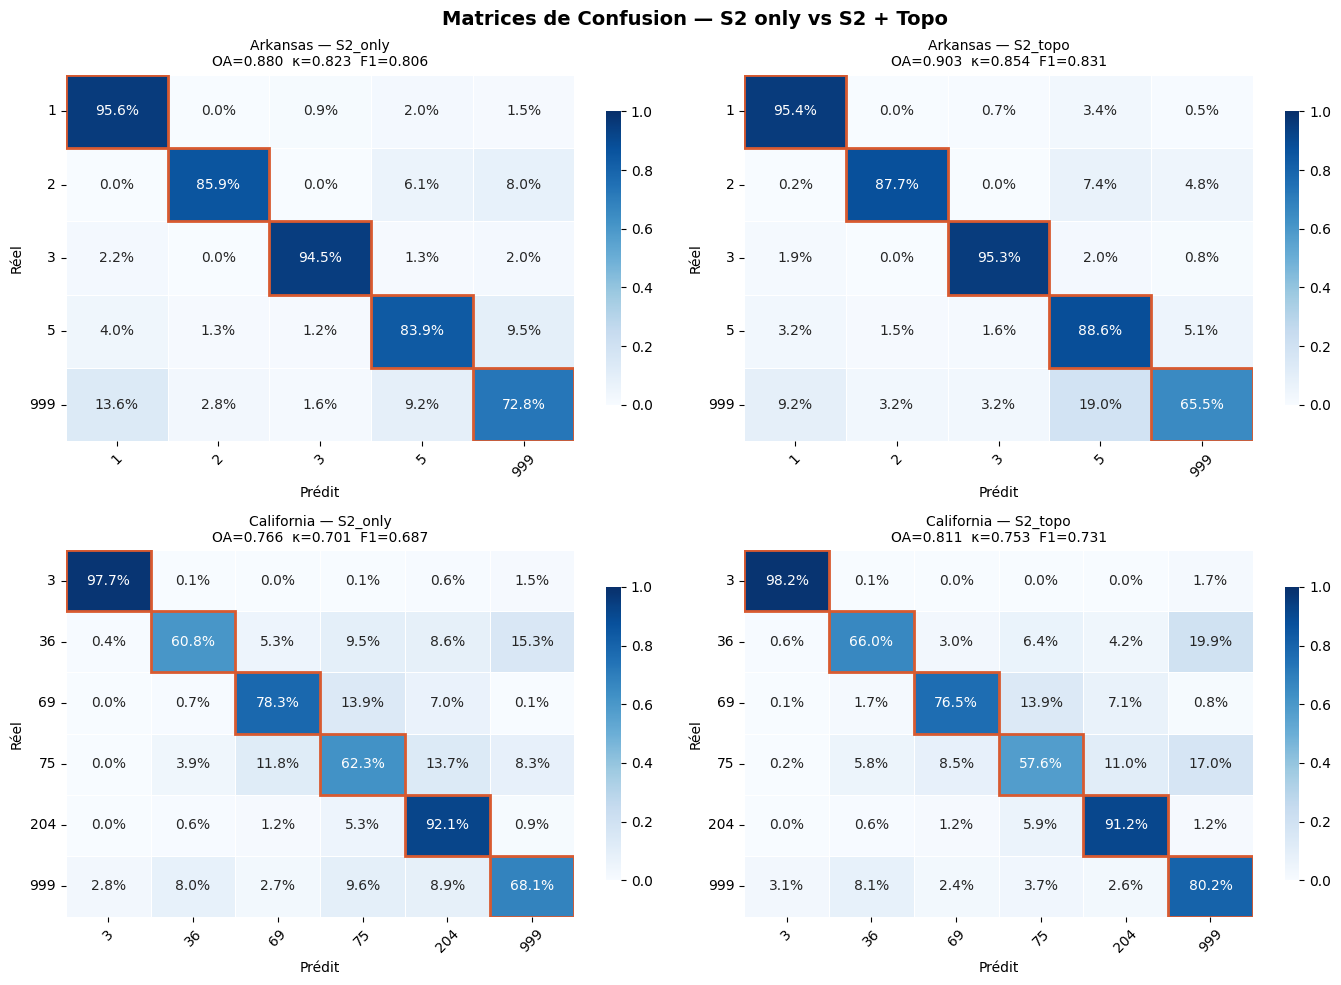

Figure sauvegardée.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

configs_to_plot = ['S2_only', 'S2_topo']
regions = {
    'Arkansas':   results['Arkansas'],
    'California': results['California'],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Matrices de Confusion — S2 only vs S2 + Topo', fontsize=14, fontweight='bold')

for row_idx, (region_name, res) in enumerate(regions.items()):
    for col_idx, cfg in enumerate(configs_to_plot):
        ax  = axes[row_idx][col_idx]
        r   = res[cfg]
        le  = r['le']

        cm      = confusion_matrix(r['y_true'], r['y_pred'])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        class_names = [str(c) for c in le.classes_]

        # Annotations en pourcentage
        annot_labels = np.array([
            [f"{v*100:.1f}%" for v in row]
            for row in cm_norm
        ])

        sns.heatmap(
            cm_norm,
            annot=annot_labels,   # pourcentages
            fmt='',               # chaîne vide car annot est déjà formaté
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8},
            vmin=0, vmax=1,
        )

        oa    = r['oa']
        kappa = r['kappa']
        f1    = r['f1']
        ax.set_title(
            f'{region_name} — {cfg}\nOA={oa:.3f}  κ={kappa:.3f}  F1={f1:.3f}',
            fontsize=10
        )
        ax.set_xlabel('Prédit',  fontsize=10)
        ax.set_ylabel('Réel',    fontsize=10)
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)

        # Diagonale en gras
        for i in range(len(class_names)):
            ax.add_patch(plt.Rectangle(
                (i, i), 1, 1,
                fill=False, edgecolor='#d85a30', lw=2
            ))

plt.tight_layout()
plt.savefig(dossier + '/matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée.")

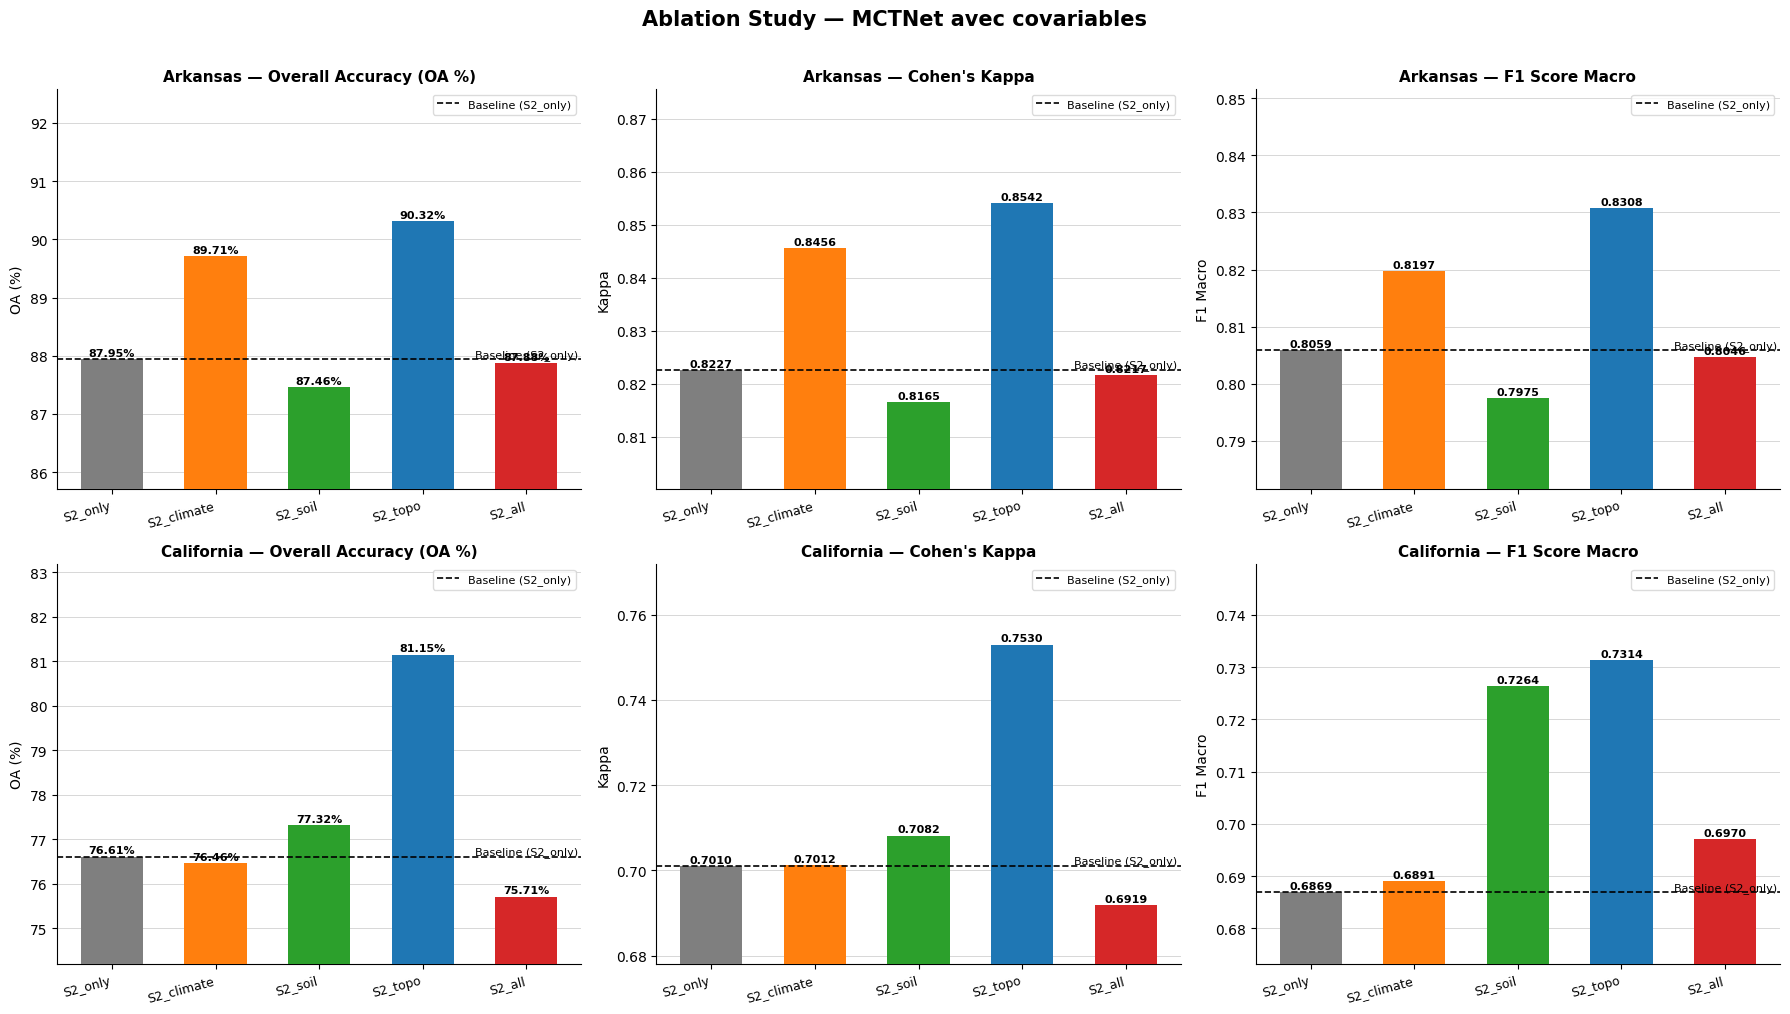

Figure sauvegardée.


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# ── Données réelles extraites des résultats ───────────────────────────────────
configs = ['S2_only', 'S2_climate', 'S2_soil', 'S2_topo', 'S2_all']
colors  = ['#7f7f7f', '#ff7f0e', '#2ca02c', '#1f77b4', '#d62728']

data = {
    'Arkansas': {
        'OA'    : [87.95, 89.71, 87.46, 90.32, 87.88],
        'Kappa' : [0.8227, 0.8456, 0.8165, 0.8542, 0.8217],
        'F1'    : [0.8059, 0.8197, 0.7975, 0.8308, 0.8046],
    },
    'California': {
        'OA'    : [76.61, 76.46, 77.32, 81.15, 75.71],
        'Kappa' : [0.7010, 0.7012, 0.7082, 0.7530, 0.6919],
        'F1'    : [0.6869, 0.6891, 0.7264, 0.7314, 0.6970],
    },
}

metrics = {
    'OA'    : {'label': 'OA (%)',    'fmt': '{:.2f}%', 'title': 'Overall Accuracy (OA %)'},
    'Kappa' : {'label': 'Kappa',     'fmt': '{:.4f}',  'title': "Cohen's Kappa"},
    'F1'    : {'label': 'F1 Macro',  'fmt': '{:.4f}',  'title': 'F1 Score Macro'},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Ablation Study — MCTNet avec covariables', fontsize=15, fontweight='bold', y=1.01)

x = np.arange(len(configs))
width = 0.6

for row_idx, (region, mdict) in enumerate(data.items()):
    for col_idx, (metric_key, meta) in enumerate(metrics.items()):
        ax     = axes[row_idx][col_idx]
        values = mdict[metric_key]
        base   = values[0]  # S2_only = baseline

        bars = ax.bar(x, values, width=width, color=colors, zorder=3)

        # Ligne baseline (S2_only)
        ax.axhline(base, color='black', linewidth=1.2, linestyle='--', zorder=4)
        ax.text(len(configs) - 0.5, base + (max(values) - min(values)) * 0.01,
                'Baseline (S2_only)', ha='right', fontsize=8, color='black')

        # Annotations sur les barres
        for bar, val in zip(bars, values):
            label = meta['fmt'].format(val)
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (max(values) - min(values)) * 0.005,
                label,
                ha='center', va='bottom', fontsize=8, fontweight='bold'
            )

        # Mise en forme
        ax.set_title(f'{region} — {meta["title"]}', fontsize=11, fontweight='bold')
        ax.set_ylabel(meta['label'], fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(configs, fontsize=9, rotation=15, ha='right')
        ax.set_ylim(min(values) * 0.98, max(values) * 1.025)
        ax.yaxis.grid(True, linewidth=0.5, alpha=0.7, zorder=0)
        ax.set_axisbelow(True)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Légende
        from matplotlib.lines import Line2D
        legend_el = [Line2D([0], [0], color='black', linewidth=1.2,
                            linestyle='--', label='Baseline (S2_only)')]
        ax.legend(handles=legend_el, fontsize=8, loc='upper right',
                  framealpha=0.8, edgecolor='lightgray')

plt.tight_layout()
plt.savefig(dossier + '/ablation_study_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée.")